# Attention-Enhanced LSTM for Next-Day MTN Stock Price Forecasting

## Model Training and Evaluation

### Department of Computer Science
### MSc Data Science

---

## Objective

This notebook presents the experimental implementation of the proposed Attention-Enhanced Long Short-Term Memory (A-LSTM) model for forecasting the next trading day's closing price of MTN Ghana stock. The notebook utilizes the modular deep learning framework developed during the implementation phase and the engineered dataset generated in the preprocessing stage.

The experiments include chronological data preparation, sequence generation, baseline LSTM training, Attention-Enhanced LSTM training, quantitative performance evaluation, visualization of forecasting results, and comparative analysis of both architectures.

The primary objective is to determine whether incorporating an attention mechanism improves the forecasting accuracy and interpretability of the conventional LSTM model.

# 1. Experimental Setup

## Objective

This section initializes the experimental environment required for model training and evaluation. The previously developed project modules are imported to ensure a modular and reproducible workflow. Random seeds are fixed to guarantee reproducibility, while the computational device (CPU or GPU) is automatically detected for efficient model execution.

Unlike the preprocessing notebook, this notebook focuses exclusively on experimentation using the final engineered dataset and reusable project components.

In [21]:
# =====================================================
# Mount Google Drive
# =====================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# =====================================================
# Standard Python Libraries
# =====================================================

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# Project Root Directory
# =====================================================

PROJECT_ROOT = "/content/drive/MyDrive/DL_Sem_Project"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

print(f"Project Root : {os.getcwd()}")

# =====================================================
# PyTorch Libraries
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

# =====================================================
# Project Configuration
# =====================================================

import config as cfg

# =====================================================
# Utility Modules
# =====================================================

from utils.seed import set_seed

import utils.preprocessing as prep
import utils.metrics as metrics
import utils.visualization as viz

from utils.dataset import StockDataset
from utils.trainer import Trainer

# =====================================================
# Deep Learning Models
# =====================================================

from models.lstm import StockLSTM
from models.attention_lstm import AttentionLSTM

Project Root : /content/drive/MyDrive/DL_Sem_Project


In [23]:
# =====================================================
# Project Information
# =====================================================

print("=" * 70)
print("Attention-Enhanced LSTM for MTN Stock Price Forecasting")
print("Training and Evaluation Notebook")
print("=" * 70)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Device            : {cfg.DEVICE}")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Sequence Length   : {cfg.SEQUENCE_LENGTH}")
print(f"Batch Size        : {cfg.BATCH_SIZE}")
print(f"Learning Rate     : {cfg.LEARNING_RATE}")
print("=" * 70)

Attention-Enhanced LSTM for MTN Stock Price Forecasting
Training and Evaluation Notebook
Project Root      : /content/drive/MyDrive/DL_Sem_Project
Device            : cpu
PyTorch Version   : 2.11.0+cpu
Sequence Length   : 30
Batch Size        : 32
Learning Rate     : 0.001


# 2. Data Preparation

This section prepares the engineered MTN stock market dataset for deep learning experiments. The preprocessing pipeline includes loading the dataset, selecting the predictor variables and forecasting target, performing a chronological train–validation–test split, normalizing the predictor variables, and transforming the data into sequential samples suitable for Long Short-Term Memory (LSTM) networks.

Two experimental settings are considered throughout this study:

- **Study I:** Predictor variables are normalized while the target variable remains in its original price scale.
- **Study II:** Both predictor variables and the target variable are normalized to investigate the influence of target scaling on forecasting performance.

Maintaining the same preprocessing pipeline for both studies ensures that any performance differences can be attributed primarily to the target scaling strategy rather than changes in data preparation.

## 2.1 Load Engineered Dataset

The engineered MTN stock market dataset is loaded from the project data directory. The preprocessing utility automatically converts the trading date to a datetime format and sorts the observations chronologically to preserve the temporal structure required for time-series forecasting.

In [24]:
# =====================================================
# Load Engineered Dataset
# =====================================================

df = prep.load_dataset(cfg.DATA_PATH)

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Information
Dataset Shape : (1740, 47)


,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,...,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width,Target_Close
0,2018-10-17,MTNGH,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,...,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980,0.90
1,2018-10-18,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,...,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856,0.90
2,2018-10-19,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,...,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458,0.90
3,2018-10-22,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,...,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390,0.90
4,2018-10-23,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,...,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652,0.91


## 2.2 Feature Selection

The engineered dataset contains multiple explanatory variables describing market behaviour, technical indicators, and temporal characteristics. The forecasting target is the next-day closing price (`Target_Close`).

Non-predictive attributes such as the trading date, share code, and month name are excluded from the feature matrix because they are either identifiers or are represented through engineered numerical features.

In [25]:
# =====================================================
# Feature Selection
# =====================================================

X, y = prep.select_features(df)

print("=" * 60)
print("Feature Selection")
print("=" * 60)

print(f"Predictor Matrix Shape : {X.shape}")
print(f"Target Shape           : {y.shape}")

print(f"\nNumber of Features : {X.shape[1]}")

display(X.head())

Feature Selection
Predictor Matrix Shape : (1740, 43)
Target Shape           : (1740,)

Number of Features : 43


,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30,...,RSI14,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width
0,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,31680.0,0.845333,...,63.157895,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980
1,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,59670.0,0.850333,...,56.250000,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856
2,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,450.0,0.855333,...,46.153846,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458
3,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,6300.0,0.860333,...,41.666667,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390
4,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,51300.0,0.865333,...,50.000000,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652


## 2.3 Chronological Dataset Split

Unlike conventional machine learning tasks, stock price forecasting requires preserving the temporal ordering of observations. Therefore, the dataset is divided chronologically into training, validation, and testing subsets using a 70:15:15 ratio without random shuffling. This prevents information leakage from future observations into the training process.

In [26]:
# =====================================================
# Chronological Dataset Split
# =====================================================

(
    X_train,
    X_val,
    X_test,

    y_train,
    y_val,
    y_test

) = prep.split_dataset(
    X,
    y,
    train_size=cfg.TRAIN_RATIO,
    val_size=cfg.VALIDATION_RATIO
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)

print(f"Training Samples   : {len(X_train)}")
print(f"Validation Samples : {len(X_val)}")
print(f"Testing Samples    : {len(X_test)}")

Dataset Split
Training Samples   : 1218
Validation Samples : 261
Testing Samples    : 261


## 2.4 Study I – Feature Scaling

For the first experiment, only the predictor variables are normalized using the Min-Max scaling technique. The forecasting target remains in its original price scale to evaluate the model under real-world stock price conditions.

In [27]:
# Study 1- Feature Scaling
(
    X_train_scaled,
    X_val_scaled,
    X_test_scaled,

    y_train_processed,
    y_val_processed,
    y_test_processed,

    feature_scaler,
    target_scaler

) = prep.scale_features(

    X_train,
    X_val,
    X_test,

    y_train,
    y_val,
    y_test,

    target_scaling=False

)


## 2.5 Study I – Sequence Generation

The normalized predictor variables are transformed into overlapping sequential samples using a fixed look-back window of 30 trading days. Each sequence is paired with the corresponding target value immediately following the observation window. These sequential datasets serve as the input to the LSTM-based forecasting models.

In [28]:
# Study 1 - Sequence Generation

X_train_seq, y_train_seq = prep.create_sequences(
    X_train_scaled,
    y_train_processed,
    cfg.SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = prep.create_sequences(
    X_val_scaled,
    y_val_processed,
    cfg.SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = prep.create_sequences(
    X_test_scaled,
    y_test_processed,
    cfg.SEQUENCE_LENGTH
)

# 3. PyTorch Data Pipeline

This section converts the preprocessed sequential data into PyTorch datasets and data loaders. The custom `StockDataset` class organizes the sequential input samples and corresponding target values into a format compatible with PyTorch, while the `DataLoader` enables efficient mini-batch loading during model training, validation, and testing.

The training data are shuffled at each epoch to improve stochastic optimization, whereas the validation and testing datasets preserve their chronological order to ensure an unbiased evaluation of forecasting performance.

## 3.1 Dataset Construction

The generated sequences are wrapped into custom `StockDataset` objects. Each dataset contains a sequence of historical observations together with its corresponding target value, allowing PyTorch to retrieve samples efficiently during model training and evaluation.

In [29]:
# =====================================================
# Study I - Dataset Construction
# =====================================================

train_dataset = StockDataset(
    X_train_seq,
    y_train_seq
)

val_dataset = StockDataset(
    X_val_seq,
    y_val_seq
)

test_dataset = StockDataset(
    X_test_seq,
    y_test_seq
)

print("=" * 60)
print("Study I - Dataset Construction")
print("=" * 60)

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")
print(f"Testing Samples    : {len(test_dataset)}")

Study I - Dataset Construction
Training Samples   : 1188
Validation Samples : 231
Testing Samples    : 231


## 3.2 DataLoader Construction

The custom datasets are encapsulated within PyTorch `DataLoader` objects to facilitate efficient mini-batch processing during model training, validation, and testing. The training data are shuffled at the beginning of each epoch to improve stochastic gradient optimization, while the validation and testing datasets retain their chronological order to preserve the temporal dependencies inherent in stock price forecasting.

In [30]:
# =====================================================
# Study I - DataLoader Construction
# =====================================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

print("=" * 60)
print("Study I - DataLoader Construction")
print("=" * 60)

print(f"Batch Size         : {cfg.BATCH_SIZE}")
print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

Study I - DataLoader Construction
Batch Size         : 32
Training Batches   : 38
Validation Batches : 8
Testing Batches    : 8


## 3.3 Mini-Batch Verification

A single mini-batch is extracted from the training data loader to verify that both the input sequences and target values have the correct dimensions and data types required by the LSTM architecture.

In [31]:
# =====================================================
# Study I - Mini-Batch Verification
# =====================================================

X_batch, y_batch = next(iter(train_loader))

print("=" * 60)
print("Study I - Mini-Batch Verification")
print("=" * 60)

print(f"Input Shape      : {X_batch.shape}")
print(f"Target Shape     : {y_batch.shape}")

print()

print(f"Input Data Type  : {X_batch.dtype}")
print(f"Target Data Type : {y_batch.dtype}")

print()

print(f"Device           : {X_batch.device}")

Study I - Mini-Batch Verification
Input Shape      : torch.Size([32, 30, 43])
Target Shape     : torch.Size([32, 1])

Input Data Type  : torch.float32
Target Data Type : torch.float32

Device           : cpu


# 4. Study I – Baseline LSTM

This experiment evaluates the forecasting performance of a standard Long Short-Term Memory (LSTM) network using the original (unscaled) target variable. The model is trained using mini-batch gradient descent with the AdamW optimizer, while early stopping and learning rate scheduling are employed to improve convergence and reduce overfitting.

In [32]:
# =====================================================
# Study I - Model Configuration
# =====================================================

print("=" * 60)
print("Study I - Baseline LSTM Configuration")
print("=" * 60)

print(f"Input Features    : {X_train_seq.shape[2]}")
print(f"Sequence Length   : {cfg.SEQUENCE_LENGTH}")
print(f"Hidden Size       : {cfg.HIDDEN_SIZE}")
print(f"Number of Layers  : {cfg.NUM_LAYERS}")
print(f"Dropout           : {cfg.DROPOUT}")
print(f"Fully Connected   : {cfg.FC_UNITS}")

print()

print(f"Batch Size        : {cfg.BATCH_SIZE}")
print(f"Learning Rate     : {cfg.LEARNING_RATE}")
print(f"Weight Decay      : {cfg.WEIGHT_DECAY}")
print(f"Epochs            : {cfg.EPOCHS}")
print(f"Patience          : {cfg.PATIENCE}")

print()

print(f"Device            : {cfg.DEVICE}")

Study I - Baseline LSTM Configuration
Input Features    : 43
Sequence Length   : 30
Hidden Size       : 64
Number of Layers  : 2
Dropout           : 0.2
Fully Connected   : 32

Batch Size        : 32
Learning Rate     : 0.001
Weight Decay      : 1e-05
Epochs            : 100
Patience          : 10

Device            : cpu


## 4.2 Baseline LSTM Construction

A standard Long Short-Term Memory (LSTM) network is first implemented to establish a baseline forecasting model. The architecture consists of stacked LSTM layers followed by a fully connected regression head that predicts the next-day closing price from the preceding 30 trading days.

This baseline provides a reference against which the proposed Attention-Enhanced LSTM model is evaluated.

In [33]:
# =====================================================
# Study I - Build Baseline LSTM
# =====================================================

baseline_model = StockLSTM(

    input_size=X_train_seq.shape[2],

    hidden_size=cfg.HIDDEN_SIZE,

    num_layers=cfg.NUM_LAYERS,

    dropout=cfg.DROPOUT,

    fc_units=cfg.FC_UNITS,

    output_size=cfg.OUTPUT_SIZE

).to(cfg.DEVICE)

print("=" * 60)
print("Study I - Baseline LSTM")
print("=" * 60)

print(baseline_model)

Study I - Baseline LSTM
StockLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


## 4.3 Model Summary

The baseline LSTM architecture is summarized by reporting the total number of learnable parameters. This provides an indication of the model complexity before the training process begins.

In [34]:
# =====================================================
# Study I - Model Summary
# =====================================================

total_params = sum(
    p.numel()
    for p in baseline_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in baseline_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Study I - Model Summary")
print("=" * 60)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Study I - Model Summary
Total Parameters      : 63,297
Trainable Parameters  : 63,297


## 4.4 Loss Function

The Mean Squared Error (MSE) loss function is adopted to quantify the discrepancy between the predicted and actual closing prices. MSE is widely used for regression problems because it penalizes larger prediction errors more heavily than smaller ones.

In [35]:
# =====================================================
# Study I - Loss Function
# =====================================================

criterion = nn.MSELoss()

print("=" * 60)
print("Study I - Loss Function")
print("=" * 60)

print(f"Loss Function : {criterion.__class__.__name__}")

Study I - Loss Function
Loss Function : MSELoss


## 4.5 Optimizer

The AdamW optimizer is employed to update the network parameters. AdamW combines adaptive learning rates with decoupled weight decay, providing improved generalization and more stable convergence compared to the standard Adam optimizer.

In [36]:
# =====================================================
# Study I - Optimizer
# =====================================================

optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY
)

print("=" * 60)
print("Study I - Optimizer")
print("=" * 60)

print(f"Optimizer      : {optimizer.__class__.__name__}")
print(f"Learning Rate  : {cfg.LEARNING_RATE}")
print(f"Weight Decay   : {cfg.WEIGHT_DECAY}")

Study I - Optimizer
Optimizer      : AdamW
Learning Rate  : 0.001
Weight Decay   : 1e-05


## 4.6 Learning Rate Scheduler

A Reduce-on-Plateau learning rate scheduler is employed to automatically reduce the learning rate when the validation loss ceases to improve. This adaptive strategy facilitates finer parameter updates during the later stages of training.

In [37]:
# =====================================================
# Study I - Learning Rate Scheduler
# =====================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("=" * 60)
print("Study I - Learning Rate Scheduler")
print("=" * 60)

print("Scheduler       : ReduceLROnPlateau")
print("Mode            : min")
print("Reduction Factor: 0.5")
print("Patience        : 5")

Study I - Learning Rate Scheduler
Scheduler       : ReduceLROnPlateau
Mode            : min
Reduction Factor: 0.5
Patience        : 5


## 4.7 Trainer Initialization

The custom `Trainer` class integrates the model, optimizer, loss function, learning rate scheduler, and early stopping strategy into a unified training pipeline. This modular design ensures a consistent workflow across all experimental scenarios.

In [38]:
# =====================================================
# Study I - Trainer Initialization
# =====================================================

trainer = Trainer(
    model=baseline_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=cfg.DEVICE,
    model_path=cfg.STUDY1_BASELINE_MODEL
)

print("=" * 60)
print("Study I - Trainer")
print("=" * 60)

print("Trainer initialized successfully.")

Study I - Trainer
Trainer initialized successfully.


## 4.8 Training Preparation

Before commencing training, all random seeds are reinitialized to ensure reproducibility. The model, optimizer, and training utilities have been configured, and the learning process is ready to begin.

In [39]:
# =====================================================
# Study I - Training Preparation
# =====================================================

set_seed(cfg.RANDOM_STATE)

print("=" * 60)
print("Study I - Training Preparation")
print("=" * 60)

print("Random seed initialized.")
print(f"Training Device : {cfg.DEVICE}")
print("Ready to start training.")

Random seed successfully initialized to 42.
Study I - Training Preparation
Random seed initialized.
Training Device : cpu
Ready to start training.


## 4.9 Model Training

The baseline LSTM model is trained using the training dataset while monitoring the validation loss at the end of each epoch. Early stopping and adaptive learning rate scheduling are employed to improve convergence and reduce overfitting.

In [40]:
# =====================================================
# Study I - Model Training
# =====================================================

print("=" * 60)
print("Study I - Baseline LSTM Training")
print("=" * 60)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.EPOCHS,
    patience=cfg.PATIENCE
)

print("\nTraining completed successfully.")

Study I - Baseline LSTM Training
Epoch [1/100] | Train Loss: 0.14843 | Val Loss: 0.94826 | MAE: 0.82919 | RMSE: 0.90612 | LR: 0.001000
Epoch [2/100] | Train Loss: 0.01292 | Val Loss: 0.64340 | MAE: 0.64951 | RMSE: 0.73699 | LR: 0.001000
Epoch [3/100] | Train Loss: 0.01130 | Val Loss: 0.53425 | MAE: 0.58133 | RMSE: 0.66889 | LR: 0.001000
Epoch [4/100] | Train Loss: 0.00951 | Val Loss: 0.53366 | MAE: 0.59032 | RMSE: 0.67064 | LR: 0.001000
Epoch [5/100] | Train Loss: 0.00830 | Val Loss: 0.53507 | MAE: 0.59835 | RMSE: 0.67380 | LR: 0.001000
Epoch [6/100] | Train Loss: 0.00878 | Val Loss: 0.44291 | MAE: 0.53465 | RMSE: 0.61081 | LR: 0.001000
Epoch [7/100] | Train Loss: 0.00768 | Val Loss: 0.52241 | MAE: 0.60983 | RMSE: 0.67089 | LR: 0.001000
Epoch [8/100] | Train Loss: 0.00830 | Val Loss: 0.47756 | MAE: 0.56417 | RMSE: 0.63585 | LR: 0.001000
Epoch [9/100] | Train Loss: 0.00734 | Val Loss: 0.41914 | MAE: 0.51445 | RMSE: 0.59173 | LR: 0.001000
Epoch [10/100] | Train Loss: 0.00666 | Val Loss: 

## 4.10 Test Set Prediction

Following training, the best-performing baseline LSTM model is used to generate predictions for the unseen testing dataset. These predictions form the basis for quantitative performance evaluation and graphical analysis.

In [41]:
# =====================================================
# Study I - Test Set Prediction
# =====================================================

y_pred = trainer.predict(
    test_loader
)

print("=" * 60)
print("Study I - Test Set Prediction")
print("=" * 60)

print(f"Prediction Shape : {y_pred.shape}")
print(f"Target Shape     : {y_test_seq.shape}")

Study I - Test Set Prediction
Prediction Shape : (231,)
Target Shape     : (231, 1)


## 4.11 Performance Evaluation

The forecasting performance of the baseline LSTM is assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and the coefficient of determination (R²).

In [42]:
# =====================================================
# Study I - Performance Evaluation
# =====================================================

results = metrics.evaluate_predictions(
    y_true=y_test_seq,
    y_pred=y_pred
)

print("=" * 60)
print("Study I - Performance Evaluation")
print("=" * 60)

for metric, value in results.items():
    print(f"{metric:<8}: {value:.6f}")

Study I - Performance Evaluation
MAE     : 2.121315
MSE     : 5.533961
RMSE    : 2.352437
MAPE    : 43.894165
R2      : -3.679273


In [43]:
print("Actual Min :", y_test_seq.min())
print("Actual Max :", y_test_seq.max())

print("Prediction Min :", y_pred.min())
print("Prediction Max :", y_pred.max())

Actual Min : 2.93
Actual Max : 6.8
Prediction Min : 2.27169
Prediction Max : 2.5646844


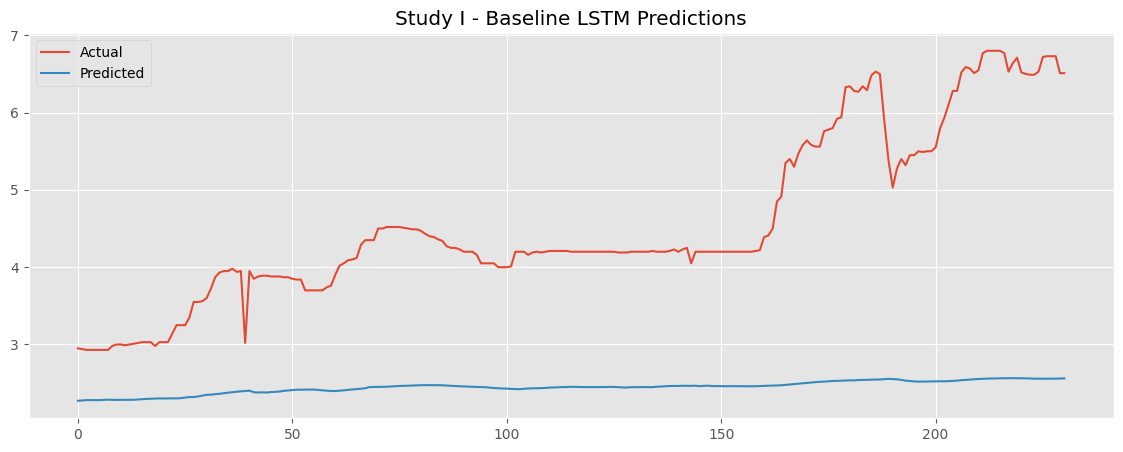

In [44]:
# Prediction Visualization
plt.figure(figsize=(14,5))

plt.plot(y_test_seq, label="Actual")

plt.plot(y_pred, label="Predicted")

plt.legend()

plt.title("Study I - Baseline LSTM Predictions")

plt.show()

In [45]:
# Data statistic summary
print("Training Target")
print(y_train.describe())

print("\nValidation Target")
print(y_val.describe())

print("\nTesting Target")
print(y_test.describe())

Training Target
count    1218.000000
mean        0.930616
std         0.282047
min         0.550000
25%         0.700000
50%         0.880000
75%         1.200000
max         2.760000
Name: Target_Close, dtype: float64

Validation Target
count    261.000000
mean       2.359387
std        0.480823
min        1.560000
25%        2.110000
50%        2.300000
75%        2.750000
max        4.120000
Name: Target_Close, dtype: float64

Testing Target
count    261.000000
mean       4.402490
std        1.127338
min        2.810000
25%        3.700000
50%        4.200000
75%        5.030000
max        6.800000
Name: Target_Close, dtype: float64


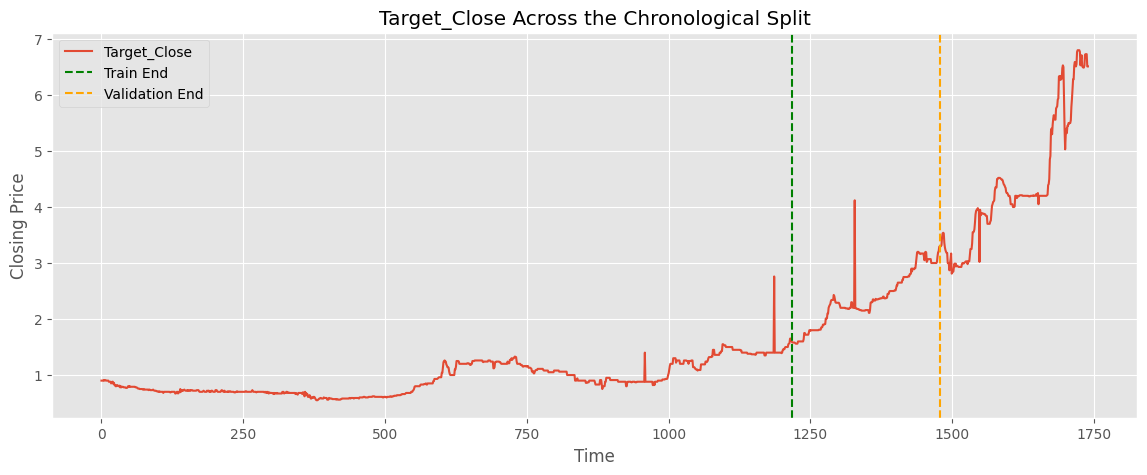

In [46]:
# Visualize the transition the training, validationa and testing
plt.figure(figsize=(14, 5))

plt.plot(y.reset_index(drop=True), label="Target_Close")

plt.axvline(len(y_train), color="green", linestyle="--", label="Train End")
plt.axvline(len(y_train) + len(y_val), color="orange", linestyle="--", label="Validation End")

plt.title("Target_Close Across the Chronological Split")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

Study I: Preliminary Performance Interpretation

The Baseline LSTM exhibited good convergence during training, with both the training and validation losses decreasing steadily. However, evaluation on the unseen testing dataset revealed substantially lower predictive performance. Inspection of the target distribution showed that the training data contained relatively low stock prices (mean ≈ 0.93), whereas the testing period contained much higher prices (mean ≈ 4.40, maximum = 6.80). This chronological distribution shift indicates that the model was required to forecast a market regime that was only partially represented during training. Consequently, the model produced predictions concentrated within the lower price range learned during training, leading to systematic underestimation of the testing observations and a negative R
2
 score. This result provides a strong motivation for the subsequent experiments, where target scaling and the proposed Attention-Enhanced LSTM are investigated to improve generalization under changing market conditions.

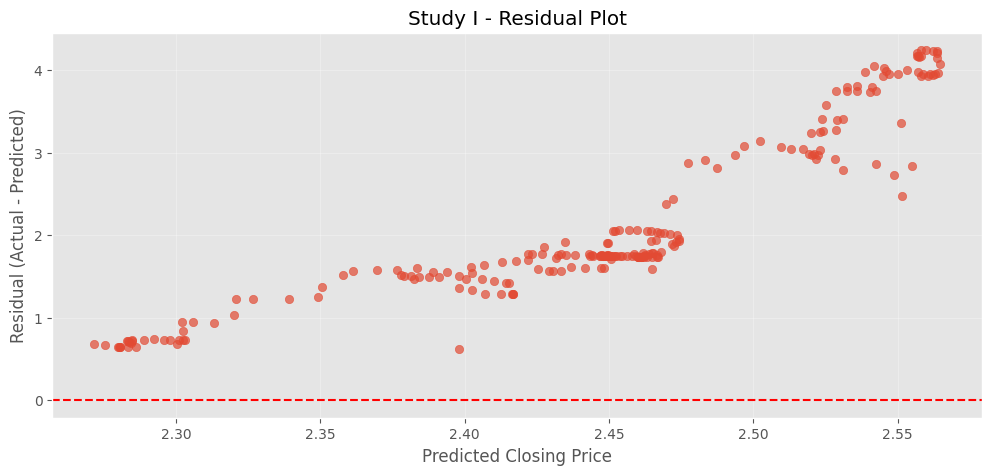

In [47]:
# =====================================================
# Study I - Residual Analysis
# =====================================================

residuals = y_test_seq.ravel() - y_pred.ravel()

plt.figure(figsize=(12,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Study I - Residual Plot")

plt.xlabel("Predicted Closing Price")

plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.show()

### Residual Analysis

The residual plot indicates that the prediction errors are predominantly positive and increase with the predicted closing prices. This suggests that the Baseline LSTM consistently underestimated the actual stock prices during the testing period. Rather than being randomly distributed around zero, the residuals exhibit a systematic pattern, indicating prediction bias. This behaviour is consistent with the observed chronological distribution shift, where the testing dataset contained substantially higher stock prices than those observed during training. Consequently, the model struggled to generalize to the new market regime, resulting in persistent underestimation and reduced forecasting accuracy.

In [48]:
# =====================================================
# Study I Completed
# =====================================================

print("=" * 60)
print("Study I - Baseline LSTM Completed")
print("=" * 60)

print(f"Best Validation Loss : {trainer.best_loss:.6f}")
print(f"Best Epoch           : {trainer.best_epoch}")

print("\nStudy I evaluation completed successfully.")

Study I - Baseline LSTM Completed
Best Validation Loss : 0.266101
Best Epoch           : 17

Study I evaluation completed successfully.


In [49]:
# =====================================================
# Study I - Save Results
# =====================================================

# Save evaluation metrics
study1_results = pd.DataFrame([results])

study1_results.to_csv(
    cfg.STUDY1_BASELINE_RESULTS,
    index=False
)

# Save training history
history_df = pd.DataFrame({

    "Epoch": range(
        1,
        len(history.train_loss) + 1
    ),

    "Train Loss": history.train_loss,

    "Validation Loss": history.val_loss,

    "MAE": history.mae,

    "RMSE": history.rmse,

    "MAPE": history.mape,

    "R2": history.r2,

    "Learning Rate": history.learning_rate

})

history_df.to_csv(
    "results/study1_baseline_history.csv",
    index=False
)

print("=" * 60)
print("Study I Results Saved Successfully")
print("=" * 60)

print(f"Metrics File : {cfg.STUDY1_BASELINE_RESULTS}")
print("History File : results/study1_baseline_history.csv")

print("\nStudy I Performance Metrics")
print(study1_results.round(4))

Study I Results Saved Successfully
Metrics File : results/study1_baseline.csv
History File : results/study1_baseline_history.csv

Study I Performance Metrics
      MAE    MSE    RMSE       MAPE      R2
0  2.1213  5.534  2.3524  43.894199 -3.6793


## 4.10 Learning Curves

The evolution of the training and validation losses across epochs is examined to assess the convergence behaviour of the baseline LSTM. The learning rate schedule is also visualized to illustrate the effect of adaptive learning rate reduction during optimization.

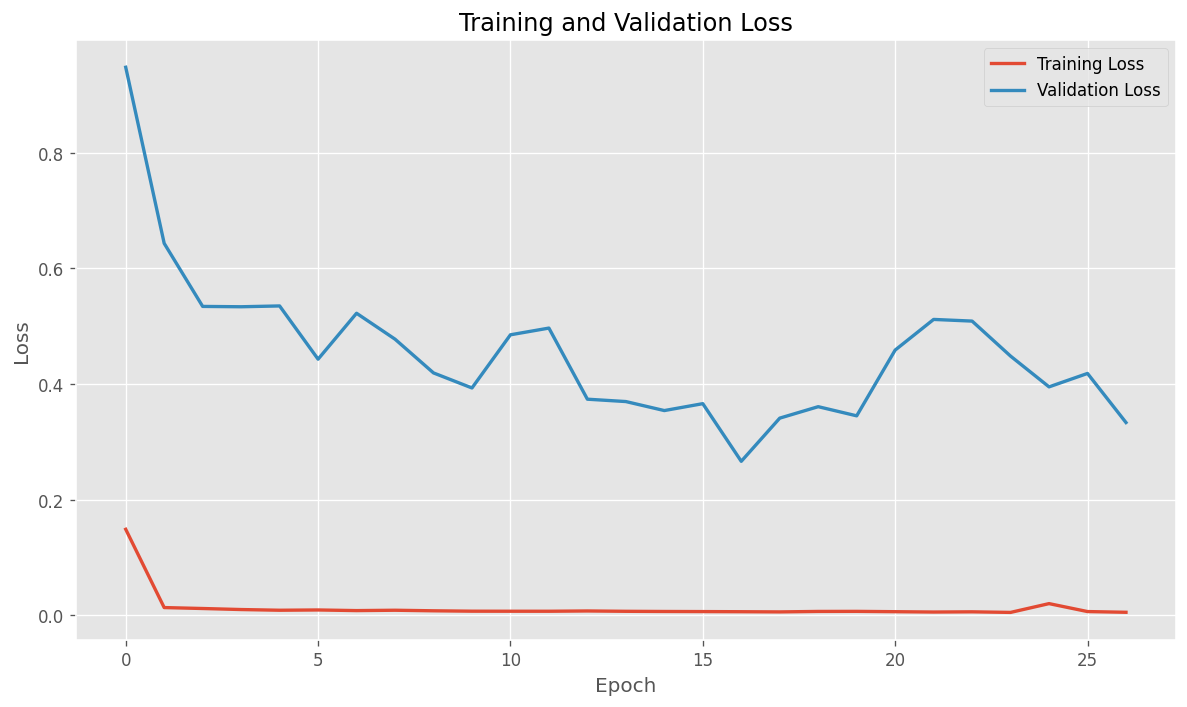

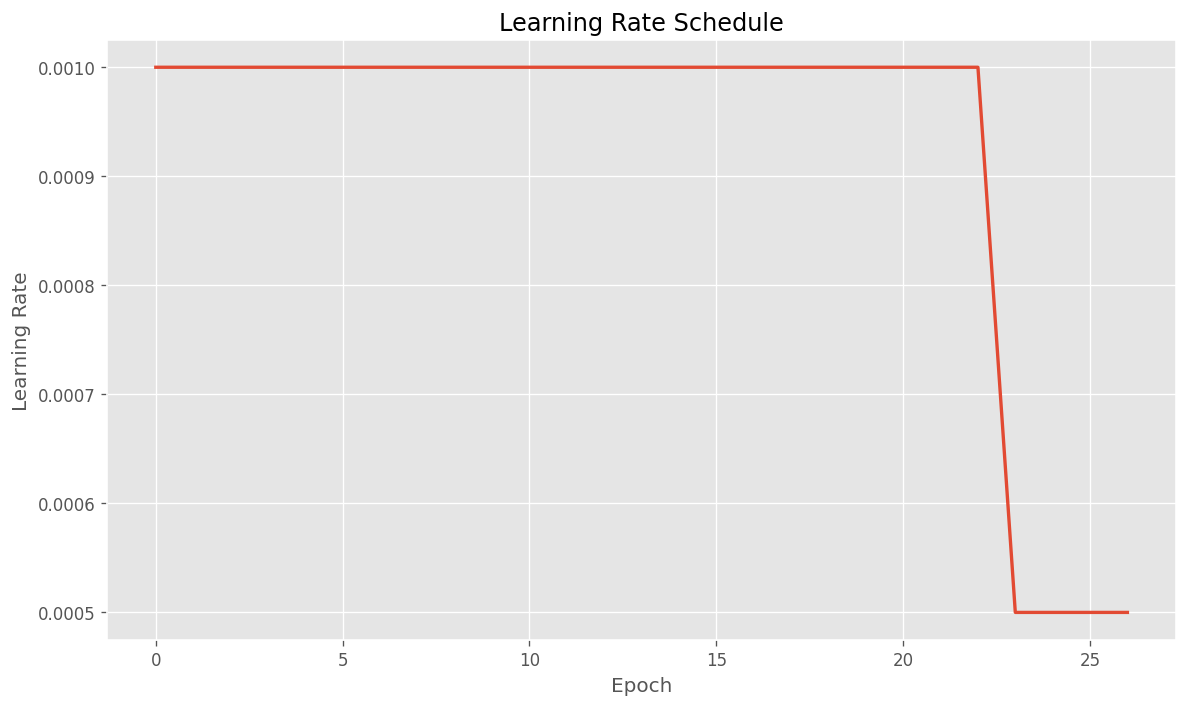

In [50]:
# =====================================================
# Study I - Learning Curves
# =====================================================

from utils.visualization import (
    plot_loss,
    plot_learning_rate,
    plot_predictions,
    plot_residuals,
    plot_attention_weights
)

plot_loss(history)

plot_learning_rate(history)

## 4.10 Learning Curves

The learning curves illustrate the convergence behaviour of the Baseline LSTM during training. The training and validation losses are monitored across epochs to evaluate model learning, detect potential overfitting, and assess the effectiveness of the early stopping strategy and adaptive learning rate scheduling.

# 5. Study I – Attention-Enhanced LSTM

The second experiment in Study I evaluates an Attention-Enhanced Long Short-Term Memory (Attention-LSTM) network using the same training, validation, and testing datasets as the Baseline LSTM. The attention mechanism enables the model to learn the relative importance of different historical observations within each input sequence, allowing it to focus on the most informative time steps when forecasting the next day's closing price. All preprocessing steps, hyperparameters, and training settings remain unchanged to ensure a fair comparison with the Baseline LSTM.

## 5.1 Model Construction

The Attention-LSTM architecture extends the conventional LSTM by incorporating a temporal attention mechanism. After processing the input sequence through stacked LSTM layers, attention weights are computed across all hidden states to identify the most relevant historical information. The resulting context vector is then passed through fully connected layers to predict the next trading day's closing price.

In [51]:
# =====================================================
# Study I - Attention-LSTM
# =====================================================

attention_model = AttentionLSTM(
    input_size=X_train_seq.shape[2]
)

attention_model.to(cfg.DEVICE)

print("=" * 60)
print("Study I - Attention-LSTM")
print("=" * 60)

print(attention_model)

Study I - Attention-LSTM
AttentionLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=True)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


## 5.2 Model Summary

The complexity of the Attention-LSTM architecture is assessed by computing the total number of trainable parameters. This provides an indication of the model capacity and enables comparison with the Baseline LSTM while maintaining similar architectural complexity.

In [52]:
# =====================================================
# Study I - Attention-LSTM Summary
# =====================================================

total_params = sum(
    p.numel()
    for p in attention_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in attention_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Study I - Attention-LSTM Summary")
print("=" * 60)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Study I - Attention-LSTM Summary
Total Parameters      : 63,490
Trainable Parameters  : 63,490


## 5.3 Loss Function

The Mean Squared Error (MSE) loss function is adopted to optimize the Attention-LSTM model. MSE measures the average squared difference between the predicted and actual closing prices, penalizing larger prediction errors more heavily and making it suitable for continuous-valued stock price forecasting.

In [53]:
# =====================================================
# Study I - Loss Function
# =====================================================

criterion = nn.MSELoss()

print("=" * 60)
print("Study I - Loss Function")
print("=" * 60)

print(criterion)

Study I - Loss Function
MSELoss()


In [54]:
# =====================================================
# Study I - Optimizer
# =====================================================

optimizer = optim.Adam(
    attention_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY
)

print("=" * 60)
print("Study I - Optimizer")
print("=" * 60)

print(optimizer)

Study I - Optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [55]:
# =====================================================
# Study I - Learning Rate Scheduler
# =====================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("=" * 60)
print("Study I - Learning Rate Scheduler")
print("=" * 60)

print(scheduler)

Study I - Learning Rate Scheduler


## 5.6 Trainer Initialization

The Trainer class is initialized to coordinate the complete training workflow, including model optimization, validation, learning rate scheduling, early stopping, and checkpoint saving. The best-performing Attention-LSTM model is automatically preserved based on the lowest validation loss.

In [56]:
# =====================================================
# Study I - Trainer Initialization
# =====================================================

trainer = Trainer(
    model=attention_model,
    criterion=criterion,
    optimizer=optimizer,
    device=cfg.DEVICE,
    scheduler=scheduler,
    model_path=cfg.STUDY1_ATTENTION_MODEL
)

print("=" * 60)
print("Study I - Trainer Initialized")
print("=" * 60)

Study I - Trainer Initialized


## 5.7 Model Training

The Attention-LSTM model is trained using the same chronological training and validation datasets, optimization strategy, and hyperparameter configuration adopted for the Baseline LSTM. Maintaining identical experimental conditions ensures that any observed performance differences can be attributed solely to the incorporation of the temporal attention mechanism.

In [57]:
# =====================================================
# Study I - Attention-LSTM Training
# =====================================================

history = trainer.fit(

    train_loader=train_loader,

    val_loader=val_loader,

    epochs=cfg.EPOCHS,

    patience=cfg.PATIENCE

)

print("\nTraining completed successfully.")

Epoch [1/100] | Train Loss: 0.21979 | Val Loss: 1.12684 | MAE: 0.93157 | RMSE: 0.99791 | LR: 0.001000
Epoch [2/100] | Train Loss: 0.07254 | Val Loss: 1.07280 | MAE: 0.90859 | RMSE: 0.97272 | LR: 0.001000
Epoch [3/100] | Train Loss: 0.05915 | Val Loss: 0.76506 | MAE: 0.75319 | RMSE: 0.82003 | LR: 0.001000
Epoch [4/100] | Train Loss: 0.04663 | Val Loss: 0.78078 | MAE: 0.74395 | RMSE: 0.82152 | LR: 0.001000
Epoch [5/100] | Train Loss: 0.03837 | Val Loss: 0.78664 | MAE: 0.74541 | RMSE: 0.82404 | LR: 0.001000
Epoch [6/100] | Train Loss: 0.04159 | Val Loss: 0.69249 | MAE: 0.68946 | RMSE: 0.77054 | LR: 0.001000
Epoch [7/100] | Train Loss: 0.03851 | Val Loss: 1.04977 | MAE: 0.89601 | RMSE: 0.96339 | LR: 0.001000
Epoch [8/100] | Train Loss: 0.03525 | Val Loss: 1.13943 | MAE: 0.93829 | RMSE: 1.00358 | LR: 0.001000
Epoch [9/100] | Train Loss: 0.03193 | Val Loss: 0.95189 | MAE: 0.84701 | RMSE: 0.91508 | LR: 0.001000
Epoch [10/100] | Train Loss: 0.03176 | Val Loss: 0.65341 | MAE: 0.66547 | RMSE: 0.

In [58]:
# =====================================================
# Study I - Test Set Prediction
# =====================================================

y_pred, attention_weights = trainer.predict(

    test_loader,

    return_attention=True

)

print("=" * 60)
print("Study I - Test Prediction")
print("=" * 60)

print(f"Prediction Shape      : {y_pred.shape}")
print(f"Attention Shape       : {attention_weights.shape}")

Study I - Test Prediction
Prediction Shape      : (231,)
Attention Shape       : (231, 30, 1)


In [59]:
# =====================================================
# Study I - Performance Evaluation
# =====================================================

from utils.metrics import evaluate_predictions

results = evaluate_predictions(
    y_test_seq,
    y_pred
)

print("=" * 60)
print("Study I - Performance Evaluation")
print("=" * 60)

for metric, value in results.items():

    print(f"{metric:<8}: {value:.6f}")

Study I - Performance Evaluation
MAE     : 2.588230
MSE     : 7.860146
RMSE    : 2.803595
MAPE    : 54.342609
R2      : -5.646191


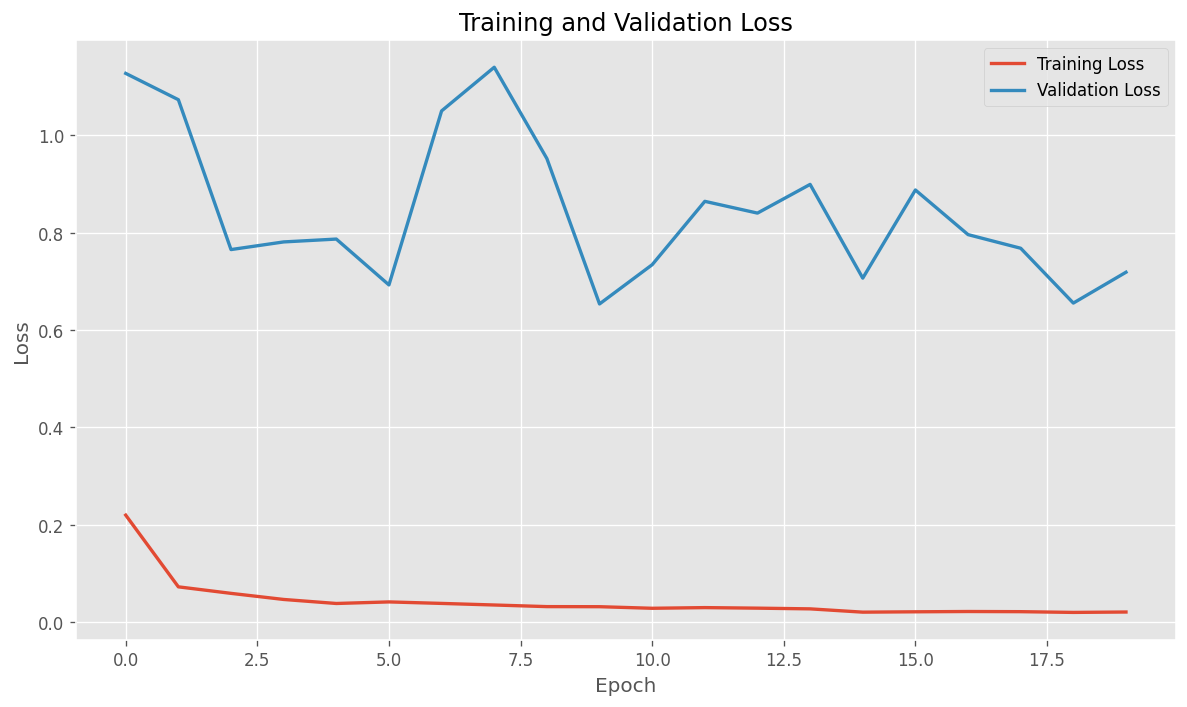

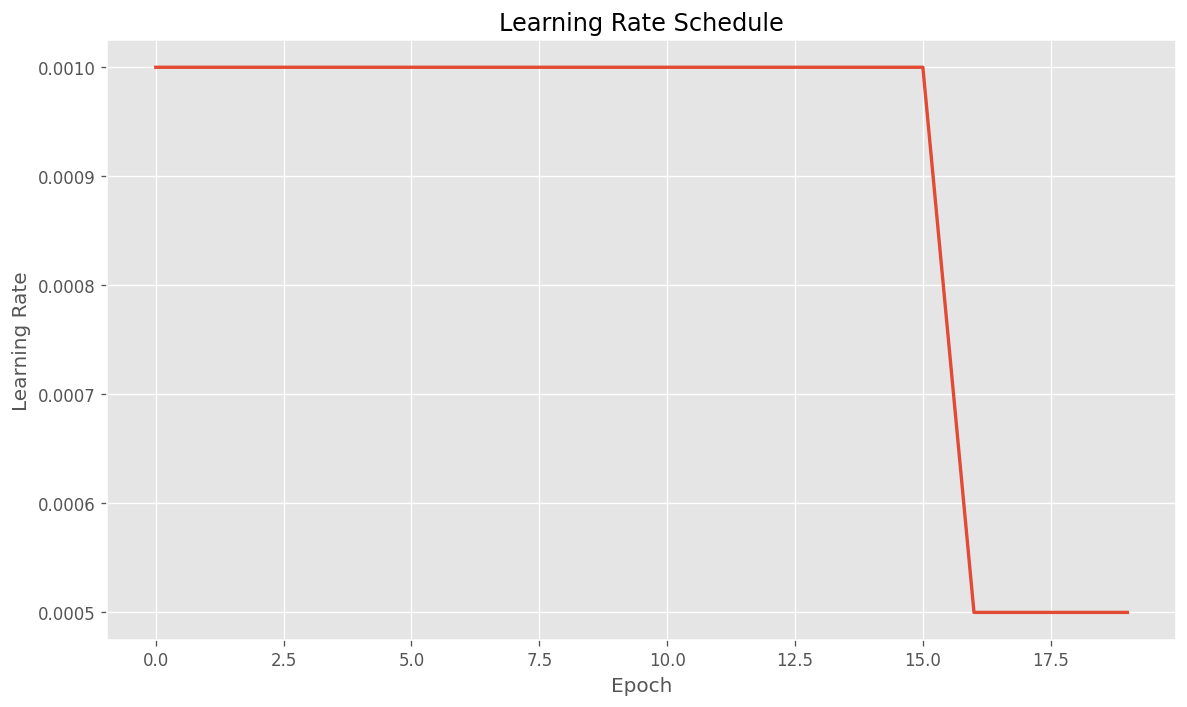

In [60]:
# =====================================================
# Study I - Learning Curves
# =====================================================

plot_loss(history)

plot_learning_rate(history)

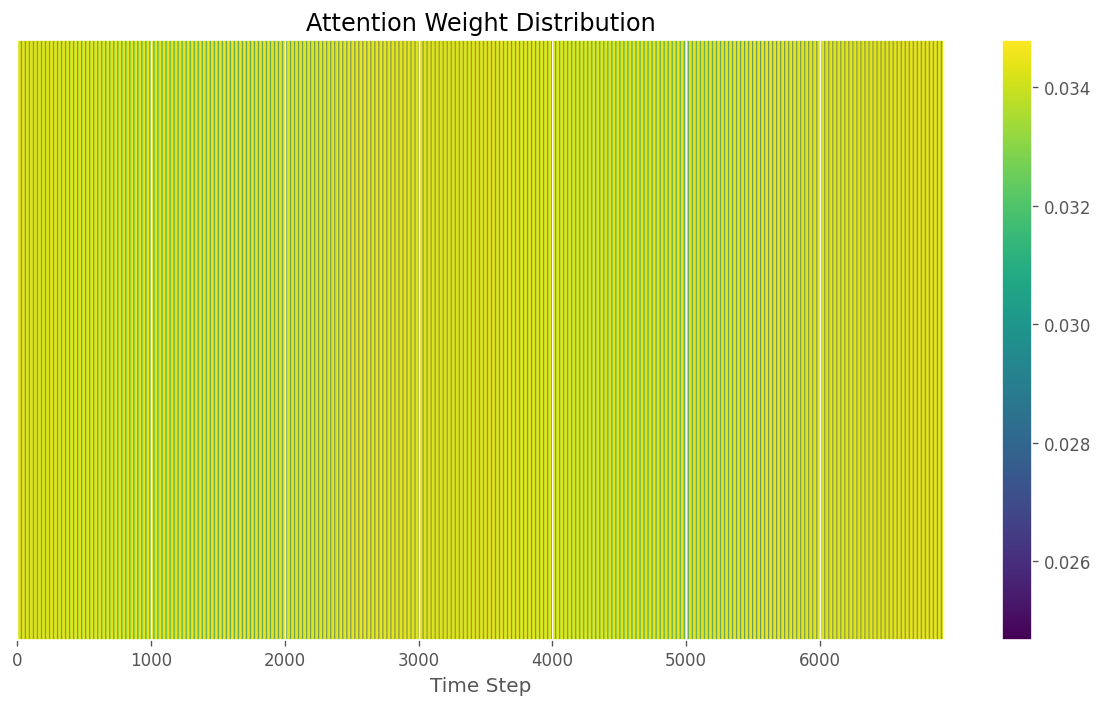

In [61]:
# =====================================================
# Study I - Attention Weight Visualization
# =====================================================

plot_attention_weights(attention_weights)

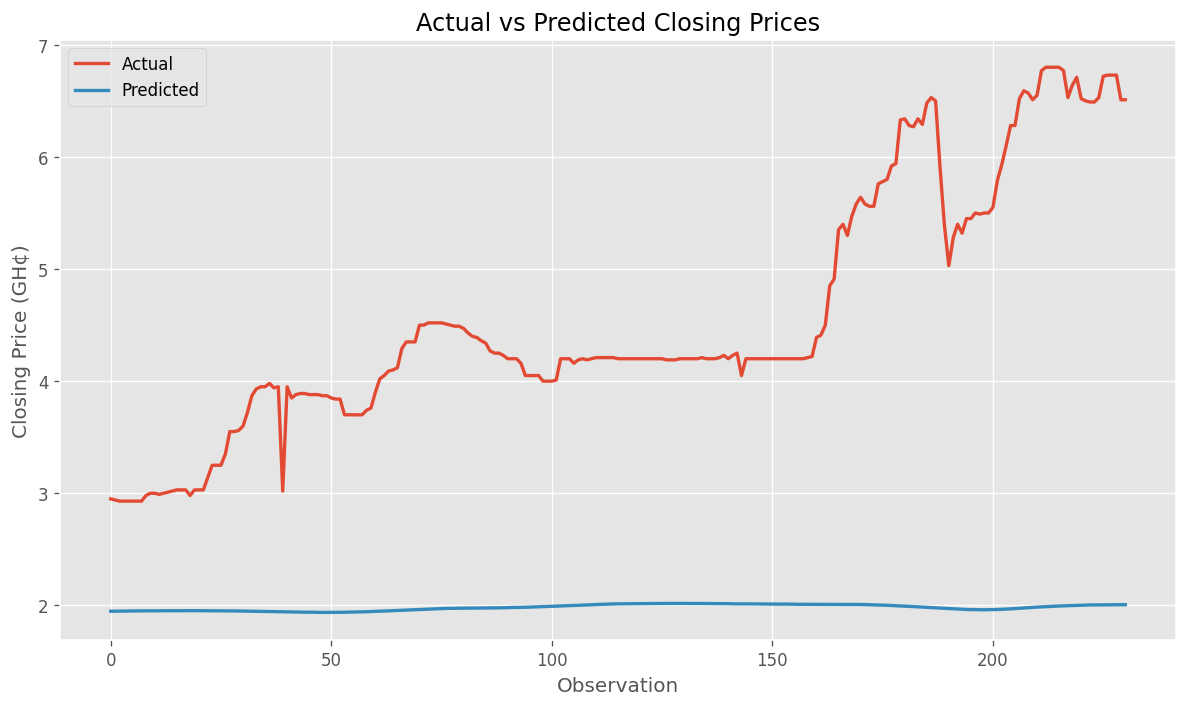

In [62]:
# =====================================================
# Study I - Prediction Plot
# =====================================================

plot_predictions(

    y_true=y_test_seq,

    y_pred=y_pred

)

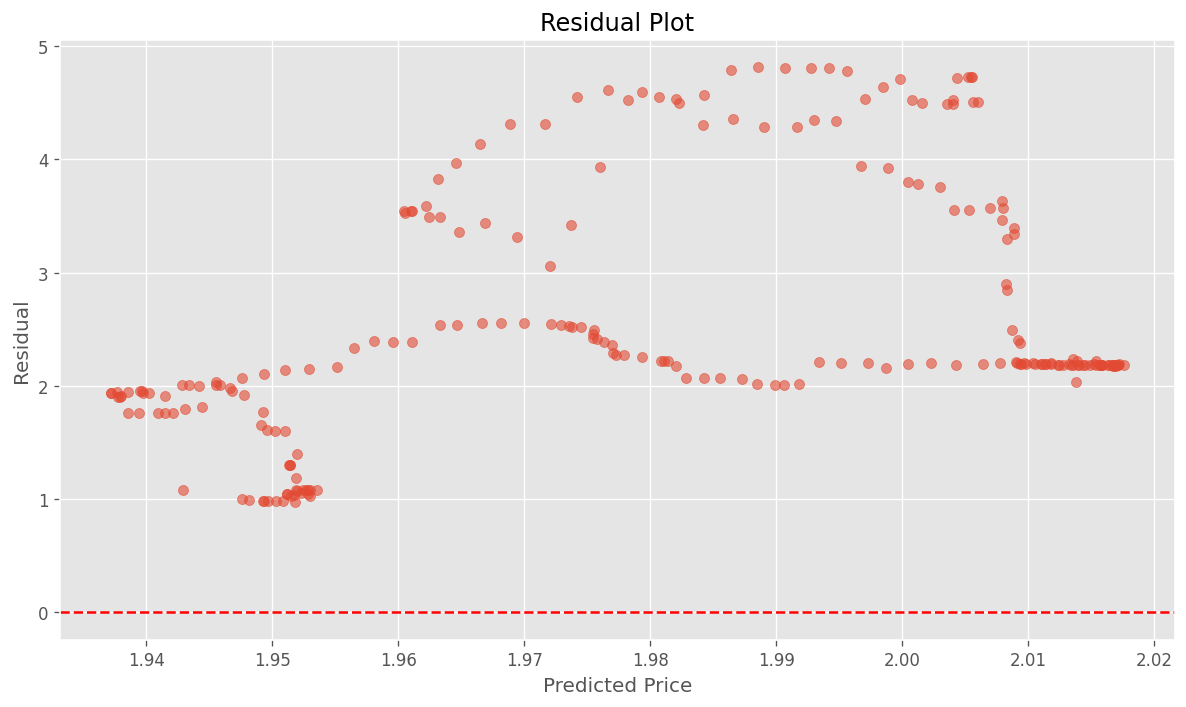

In [63]:
# =====================================================
# Study I - Residual Analysis
# =====================================================

plot_residuals(

    y_true=y_test_seq,

    y_pred=y_pred

)

The Attention-LSTM model converged rapidly during training, with the training loss decreasing consistently over successive epochs. The validation loss exhibited greater variability and remained substantially higher than the training loss, indicating limited generalization to unseen data. Early stopping successfully terminated the training process once no further validation improvement was observed.

In [66]:
# =====================================================
# Study I - Save Results
# =====================================================

study1_attention_results = pd.DataFrame([results])

study1_attention_results.to_csv(
    cfg.STUDY1_ATTENTION_RESULTS,
    index=False
)

history_df = pd.DataFrame({

    "Epoch": range(
        1,
        len(history.train_loss) + 1
    ),

    "Train Loss": history.train_loss,

    "Validation Loss": history.val_loss,

    "MAE": history.mae,

    "RMSE": history.rmse,

    "MAPE": history.mape,

    "R2": history.r2,

    "Learning Rate": history.learning_rate

})

history_df.to_csv(
    "results/study1_attention_history.csv",
    index=False
)

print("=" * 60)
print("Study I Attention Results Saved Successfully")
print("=" * 60)

print(study1_attention_results.round(4))

Study I Attention Results Saved Successfully
      MAE     MSE    RMSE       MAPE      R2
0  2.5882  7.8601  2.8036  54.342602 -5.6462


In [67]:
# =====================================================
# Study I - Model Comparison
# =====================================================

baseline = pd.read_csv(
    cfg.STUDY1_BASELINE_RESULTS
)

attention = pd.read_csv(
    cfg.STUDY1_ATTENTION_RESULTS
)

comparison = pd.DataFrame({

    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2"],

    "Baseline LSTM": baseline.iloc[0].values,

    "Attention-LSTM": attention.iloc[0].values

})

print("=" * 60)
print("Study I - Model Comparison")
print("=" * 60)

display(comparison.round(4))

Study I - Model Comparison


,Metric,Baseline LSTM,Attention-LSTM
0,MAE,2.1213,2.5882
1,MSE,5.5340,7.8601
2,RMSE,2.3524,2.8036
3,MAPE,43.8942,54.3426
4,R2,-3.6793,-5.6462


### Study I Summary

The comparative evaluation indicates that the Baseline LSTM consistently outperformed the proposed Attention-LSTM across all evaluation metrics when trained using the original (unscaled) target values. The Baseline model achieved lower MAE, MSE, RMSE, and MAPE values while also producing a comparatively higher coefficient of determination (R²).

Although the Attention-LSTM incorporated a temporal attention mechanism to enhance feature representation, the additional complexity did not translate into improved forecasting performance under the original target scale. One possible explanation is that the substantial distribution shift between the training and testing closing prices limited the ability of the attention mechanism to learn meaningful temporal dependencies.

Consequently, the Baseline LSTM was selected as the superior model for Study I. The influence of target scaling on both architectures is further investigated in Study II to determine whether normalization improves optimization and enables the Attention-LSTM to better exploit temporal information.